In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [3]:
df = pd.read_csv("diabetes_cleaned.csv")
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (229781, 22)

First 5 Rows:
   Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0           0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1           0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2           0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3           0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4           0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.

In [4]:
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Distribution:")
print(df["Diabetes_012"].value_counts().sort_index())


Missing Values:
Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Target Distribution:
Diabetes_012
0.0    190055
1.0      4629
2.0     35097
Name: count, dtype: int64


In [5]:
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]
print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)


Features Shape: (229781, 21)
Target Shape: (229781,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (183824, 21)
Testing Data: (45957, 21)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeature scaling completed.")


Feature scaling completed.


In [9]:
logistic_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [11]:
y_pred_logistic = logistic_model.predict(X_test_scaled)
print("\nLogistic Regression Predictions:")
print(y_pred_logistic[:20])


Logistic Regression Predictions:
[2. 0. 2. 1. 1. 1. 0. 2. 1. 0. 0. 0. 2. 1. 0. 0. 0. 1. 0. 1.]


In [13]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_precision = precision_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted",
    zero_division=0
)
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

Accuracy : 0.6292
Precision: 0.8369
Recall   : 0.6292
F1 Score : 0.7033


In [14]:
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=[
            "No Diabetes",
            "Prediabetes",
            "Diabetes"
        ],
        zero_division=0
    )
)

              precision    recall  f1-score   support

 No Diabetes       0.94      0.64      0.77     38012
 Prediabetes       0.03      0.30      0.06       926
    Diabetes       0.37      0.59      0.45      7019

    accuracy                           0.63     45957
   macro avg       0.45      0.51      0.43     45957
weighted avg       0.84      0.63      0.70     45957



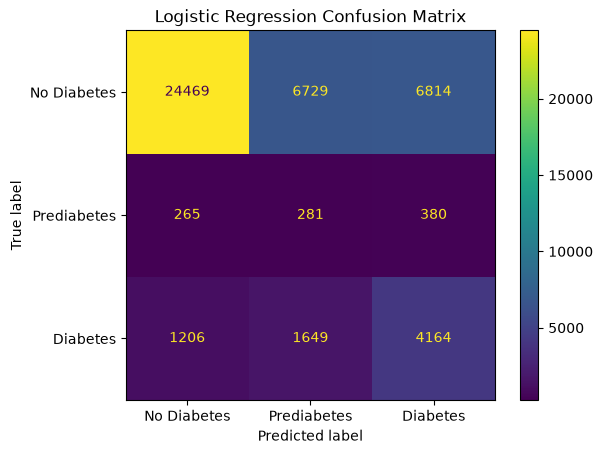

In [15]:
cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=[
        "No Diabetes",
        "Prediabetes",
        "Diabetes"
    ]
)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [16]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [17]:
y_pred_rf = random_forest.predict(X_test)

print("\nRandom Forest Predictions:")
print(y_pred_rf[:20])


Random Forest Predictions:
[2. 0. 0. 2. 0. 0. 0. 2. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 0. 0.]


In [18]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Accuracy : 0.7768
Precision: 0.7968
Recall   : 0.7768
F1 Score : 0.7839


In [19]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "No Diabetes",
            "Prediabetes",
            "Diabetes"
        ],
        zero_division=0
    )
)


              precision    recall  f1-score   support

 No Diabetes       0.89      0.84      0.87     38012
 Prediabetes       0.02      0.00      0.01       926
    Diabetes       0.37      0.53      0.44      7019

    accuracy                           0.78     45957
   macro avg       0.43      0.46      0.44     45957
weighted avg       0.80      0.78      0.78     45957



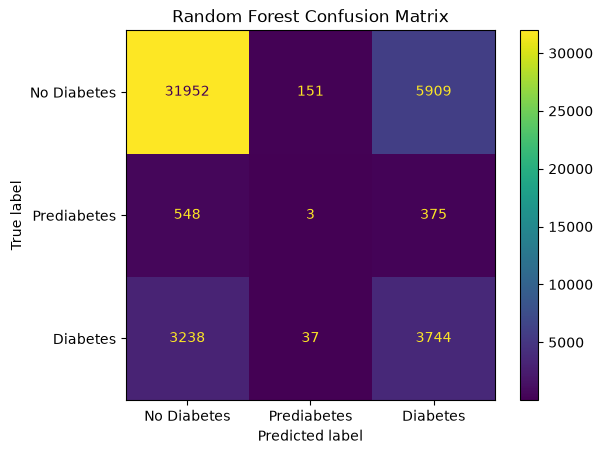

In [20]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=[
        "No Diabetes",
        "Prediabetes",
        "Diabetes"
    ]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")

plt.show()

In [21]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],

    "Precision": [
        logistic_precision,
        rf_precision
    ],

    "Recall": [
        logistic_recall,
        rf_recall
    ],

    "F1 Score": [
        logistic_f1,
        rf_f1
    ]
})
print(
    comparison.round(4)
)


                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.6292     0.8369  0.6292    0.7033
1        Random Forest    0.7768     0.7968  0.7768    0.7839


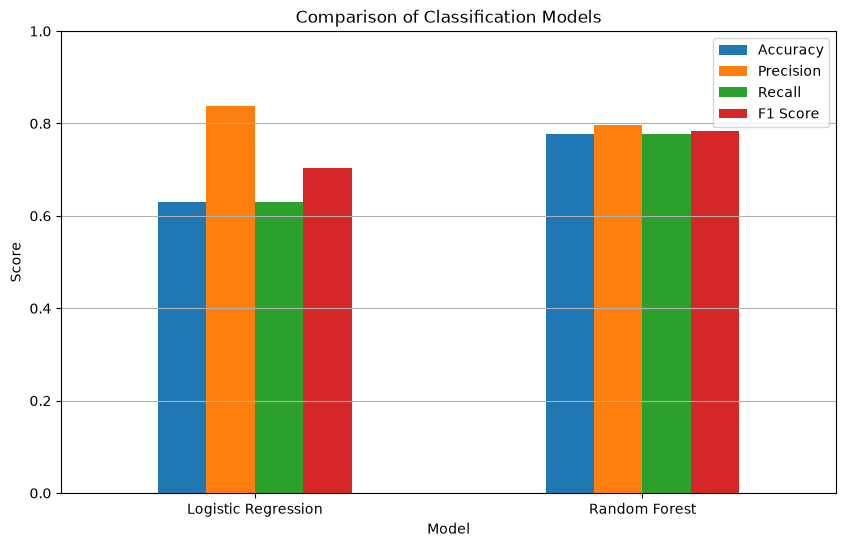

In [22]:
comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)
plt.title("Comparison of Classification Models")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


In [23]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n===== FEATURE IMPORTANCE =====")

print(
    feature_importance
)


===== FEATURE IMPORTANCE =====
                 Feature  Importance
3                    BMI    0.174974
18                   Age    0.135150
20                Income    0.103637
15              PhysHlth    0.081528
19             Education    0.074653
14              MentHlth    0.067557
13               GenHlth    0.060146
4                 Smoker    0.036960
8                 Fruits    0.036846
17                   Sex    0.032474
0                 HighBP    0.030877
7           PhysActivity    0.028985
9                Veggies    0.028312
1               HighChol    0.023806
16              DiffWalk    0.017953
12           NoDocbcCost    0.015667
6   HeartDiseaseorAttack    0.015042
5                 Stroke    0.011225
11         AnyHealthcare    0.009515
10     HvyAlcoholConsump    0.009107
2              CholCheck    0.005585


In [24]:
top_features = feature_importance.head(10)
print("\nTop 10 Important Features:")
print(top_features)


Top 10 Important Features:
      Feature  Importance
3         BMI    0.174974
18        Age    0.135150
20     Income    0.103637
15   PhysHlth    0.081528
19  Education    0.074653
14   MentHlth    0.067557
13    GenHlth    0.060146
4      Smoker    0.036960
8      Fruits    0.036846
17        Sex    0.032474


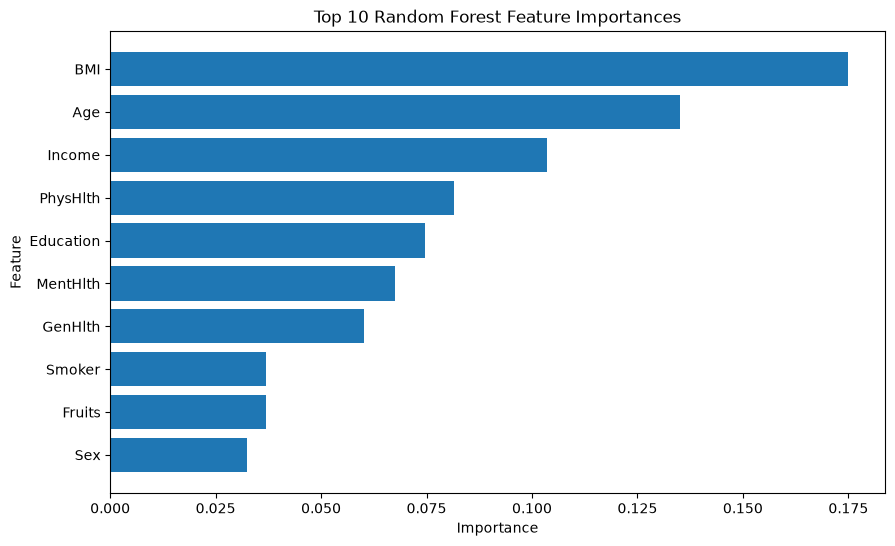

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

In [28]:
logistic_cv = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1_weighted"
)
print("\n===== LOGISTIC REGRESSION CROSS-VALIDATION =====")
print("CV Scores:", logistic_cv)
print(
    "Mean CV F1 Score:",
    round(logistic_cv.mean(), 4)
)


===== LOGISTIC REGRESSION CROSS-VALIDATION =====
CV Scores: [0.69733485 0.69793327 0.7011942  0.69919743 0.69735511]
Mean CV F1 Score: 0.6986


In [29]:
rf_cv = cross_val_score(
    random_forest,
    X_train,
    y_train,
    cv=5,
    scoring="f1_weighted"
)

print("\n===== RANDOM FOREST CROSS-VALIDATION =====")

print("CV Scores:", rf_cv)

print(
    "Mean CV F1 Score:",
    round(rf_cv.mean(), 4)
)



===== RANDOM FOREST CROSS-VALIDATION =====
CV Scores: [0.78066249 0.78103838 0.78322941 0.78240958 0.78222464]
Mean CV F1 Score: 0.7819


In [30]:
if rf_f1 > logistic_f1:

    best_model = "Random Forest"

else:

    best_model = "Logistic Regression"
print(
    "\nBest Model based on Weighted F1 Score:",
    best_model
)


Best Model based on Weighted F1 Score: Random Forest


In [31]:
comparison.to_csv(
    "week4_model_comparison.csv",
    index=False
)

print(
    "\nModel comparison saved as "
    "'week4_model_comparison.csv'"
)


Model comparison saved as 'week4_model_comparison.csv'


In [32]:
feature_importance.to_csv(
    "week4_feature_importance.csv",
    index=False
)

print(
    "Feature importance saved as "
    "'week4_feature_importance.csv'"
)


Feature importance saved as 'week4_feature_importance.csv'


In [33]:
print("\n==========================================")
print("       WEEK 4 ANALYSIS COMPLETED")
print("==========================================")

print("Target Variable: Diabetes_012")
print("Classes: 0 = No Diabetes")
print("         1 = Prediabetes")
print("         2 = Diabetes")

print("\nLogistic Regression F1:",
      round(logistic_f1, 4))

print("Random Forest F1:",
      round(rf_f1, 4))

print("\nBest Model:",
      best_model)

print("==========================================")


       WEEK 4 ANALYSIS COMPLETED
Target Variable: Diabetes_012
Classes: 0 = No Diabetes
         1 = Prediabetes
         2 = Diabetes

Logistic Regression F1: 0.7033
Random Forest F1: 0.7839

Best Model: Random Forest
